# Lab 3 — Detección de Anomalías con Machine Learning
**Estudiante:** AlessandroPastor  
**Curso:** Seguridad Informática — Unidad IV  
**Dataset:** network_traffic.csv (10,000 registros de tráfico de red)

In [2]:
import os
os.chdir('/home/pastor/examen-practico-pastor')
print("Directorio actual:", os.getcwd())

Directorio actual: /home/pastor/examen-practico-pastor


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('lab3/network_traffic.csv')
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nEstadísticas descriptivas:")
df.describe()

Shape: (10000, 10)

Columnas: ['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'label']

Estadísticas descriptivas:


,dst_port,bytes_sent,bytes_recv,duration_sec,packets
count,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04
mean,5272.963700,2.815289e+07,4.124360e+05,447.154662,1.605501e+04
std,7348.395782,3.115671e+08,1.964278e+06,4530.488171,1.672859e+05
min,21.000000,1.500000e+01,0.000000e+00,0.000000,1.000000e+00
25%,53.000000,5.544000e+03,1.328800e+04,8.507500,5.000000e+00
50%,3389.000000,2.233900e+04,5.529050e+04,21.435000,2.400000e+01
75%,8080.000000,9.478175e+04,2.213258e+05,44.145000,1.100000e+02
max,65460.000000,4.987050e+09,8.155783e+07,83028.150000,2.939448e+06


## Tarea 3.1 — Exploración y Preprocesamiento

In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nDistribución de etiquetas:")
print(df['label'].value_counts())

Valores nulos por columna:
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64

Distribución de etiquetas:
label
normal     9500
anomaly     500
Name: count, dtype: int64


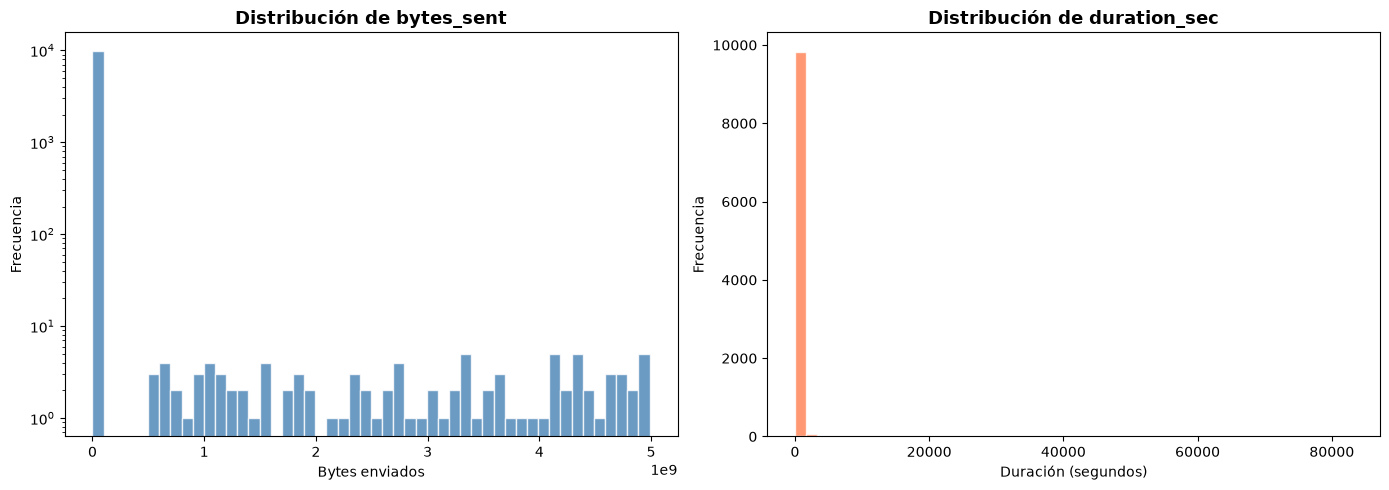

Histogramas guardados.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bytes_sent'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de bytes_sent', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bytes enviados')
axes[0].set_ylabel('Frecuencia')
axes[0].set_yscale('log')

axes[1].hist(df['duration_sec'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de duration_sec', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Duración (segundos)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('lab3/evidencias/SCR-3.1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogramas guardados.")

In [6]:
# Tratar valores nulos
df = df.fillna(df.median(numeric_only=True))

# Feature engineering: 2 nuevas variables derivadas
df['ratio_bytes'] = df['bytes_sent'] / (df['bytes_recv'] + 1)
df['bytes_por_segundo'] = (df['bytes_sent'] + df['bytes_recv']) / (df['duration_sec'] + 0.001)

print("Nuevas features creadas:")
print(df[['ratio_bytes', 'bytes_por_segundo']].describe())

Nuevas features creadas:
        ratio_bytes  bytes_por_segundo
count  1.000000e+04       1.000000e+04
mean   4.212233e+03       2.142196e+05
std    1.182686e+05       7.852883e+06
min    1.106611e-05       1.492779e-02
25%    6.337164e-02       1.984537e+03
50%    4.393979e-01       7.741513e+03
75%    3.031250e+00       3.408747e+04
max    9.151127e+06       7.749110e+08


In [7]:
# Seleccionar features numéricas para el modelo
features = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets',
            'dst_port', 'ratio_bytes', 'bytes_por_segundo']

X = df[features].copy()

# Normalizar con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features normalizadas. Shape:", X_scaled.shape)
print("\nMedia (debe ser ~0):", X_scaled.mean(axis=0).round(3))
print("Std  (debe ser ~1):", X_scaled.std(axis=0).round(3))

Features normalizadas. Shape: (10000, 7)

Media (debe ser ~0): [-0.  0.  0. -0. -0.  0. -0.]
Std  (debe ser ~1): [1. 1. 1. 1. 1. 1. 1.]


## Tarea 3.2 — Entrenamiento del Modelo

In [8]:
# Entrenar Isolation Forest
model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42
)
model.fit(X_scaled)
predicciones = model.predict(X_scaled)

# -1 = anomalía, 1 = normal
n_anomalias = (predicciones == -1).sum()
print(f"Total anomalías detectadas: {n_anomalias}")
print(f"Total normales: {(predicciones == 1).sum()}")

Total anomalías detectadas: 500
Total normales: 9500


  MÉTRICAS DE EVALUACIÓN
  Precision : 0.6160
  Recall    : 0.6160
  F1-Score  : 0.6160


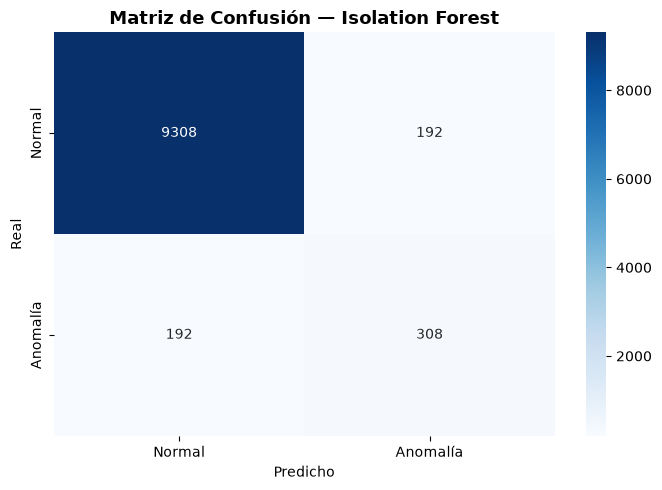

In [9]:
# Evaluar con la columna label
y_true = (df['label'] == 'anomaly').astype(int)
y_pred = (predicciones == -1).astype(int)

precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

print("=" * 40)
print("  MÉTRICAS DE EVALUACIÓN")
print("=" * 40)
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 40)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Anomalía'],
            yticklabels=['Normal','Anomalía'])
ax.set_title('Matriz de Confusión — Isolation Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('lab3/evidencias/SCR-3.2_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## Tarea 3.3 — Interpretación y Umbral Dinámico

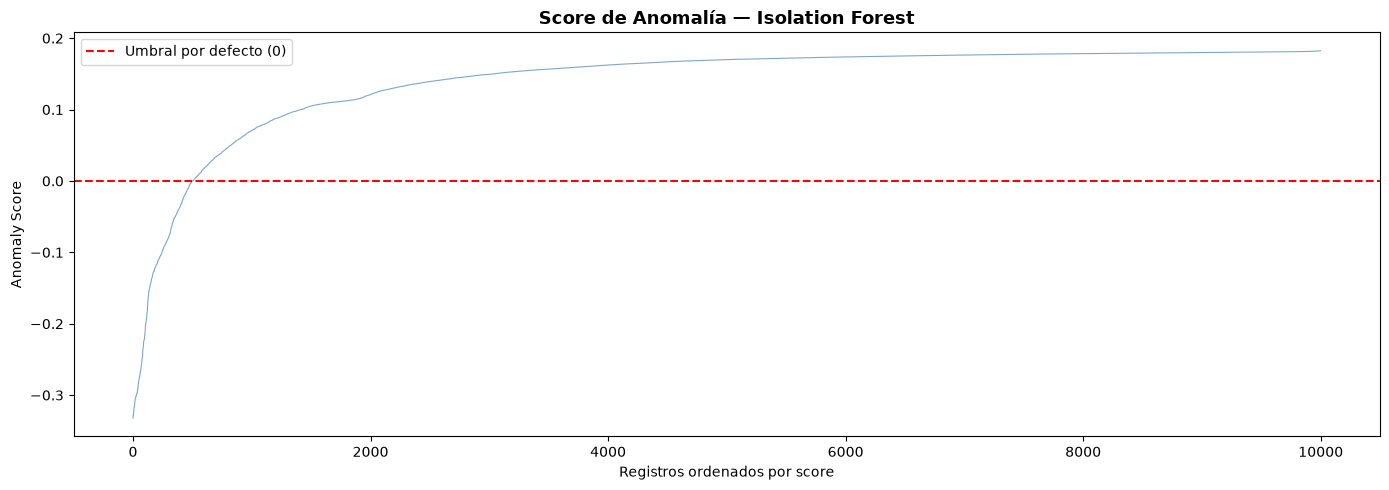

In [10]:
# Score de anomalía (decision_function)
scores = model.decision_function(X_scaled)
df['anomaly_score'] = scores

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(scores)), sorted(scores), color='steelblue', linewidth=0.8, alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', label='Umbral por defecto (0)')
ax.set_title('Score de Anomalía — Isolation Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Registros ordenados por score')
ax.set_ylabel('Anomaly Score')
ax.legend()
plt.tight_layout()
plt.show()

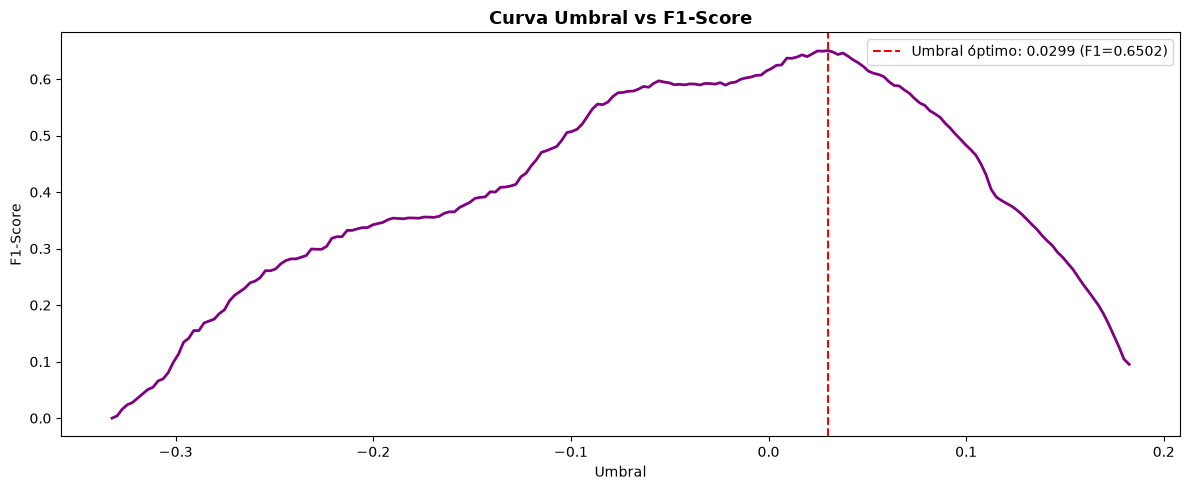

Umbral óptimo: 0.0299
F1-Score máximo: 0.6502


In [11]:
# Curva umbral vs F1-Score
umbrales = np.linspace(scores.min(), scores.max(), 200)
f1_scores = []

for u in umbrales:
    y_pred_u = (scores < u).astype(int)
    if y_pred_u.sum() == 0:
        f1_scores.append(0)
    else:
        f1_scores.append(f1_score(y_true, y_pred_u))

umbral_optimo = umbrales[np.argmax(f1_scores)]
f1_optimo = max(f1_scores)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(umbrales, f1_scores, color='purple', linewidth=2)
ax.axvline(x=umbral_optimo, color='red', linestyle='--',
           label=f'Umbral óptimo: {umbral_optimo:.4f} (F1={f1_optimo:.4f})')
ax.set_title('Curva Umbral vs F1-Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Umbral')
ax.set_ylabel('F1-Score')
ax.legend()
plt.tight_layout()
plt.savefig('lab3/evidencias/SCR-3.3_umbral_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Umbral óptimo: {umbral_optimo:.4f}")
print(f"F1-Score máximo: {f1_optimo:.4f}")

In [12]:
# Top 10 registros más anómalos
top10_anomalias = df.nsmallest(10, 'anomaly_score')
print("TOP 10 REGISTROS MÁS ANÓMALOS:")
print(top10_anomalias[['timestamp','src_ip','dst_ip','dst_port','protocol',
                         'bytes_sent','bytes_recv','duration_sec','packets',
                         'anomaly_score','label']].to_string())

TOP 10 REGISTROS MÁS ANÓMALOS:
                timestamp      src_ip          dst_ip  dst_port protocol  bytes_sent  bytes_recv  duration_sec  packets  anomaly_score    label
3773  2024-05-07 05:39:15  10.0.1.114  185.220.101.45      8080      TCP  4602183026       43276        682.60  2052006      -0.332206  anomaly
1687  2024-05-09 01:03:49  10.0.3.187  185.220.101.45       443      TCP  4706448909        9058       2778.48  2914444      -0.328858  anomaly
6456  2024-05-17 04:39:05  10.0.1.254   38.168.189.92        80      UDP  4696305972       21229        383.65  1693674      -0.328302  anomaly
6597  2024-05-04 04:44:10   10.0.0.93  185.220.101.45      8080      TCP  2739832080       11140        342.89  1882321      -0.328302  anomaly
786   2024-05-09 00:59:47  10.0.1.114   178.249.13.75        53      TCP  3385524170       18133        451.40  2532734      -0.324970  anomaly
5258  2024-05-25 04:58:47   10.0.2.73    205.91.80.48        80      TCP  4235188534        9595       19

### Análisis de los Top 10 registros anómalos

Los registros con menor `anomaly_score` representan las conexiones más alejadas 
del comportamiento normal del tráfico de red. Las características que los hacen 
sospechosos son:

- **Volumen de datos extremo**: `bytes_sent` o `bytes_recv` muy superiores a la media, 
  lo que puede indicar exfiltración de datos o descarga masiva no autorizada.
- **Duración inusual**: conexiones extremadamente largas o cortas respecto al promedio, 
  típico de tunneling o beaconing de malware.
- **Puertos inusuales**: conexiones a puertos no estándar que podrían indicar 
  comunicación con C2 (Command & Control).
- **Ratio bytes anómalo**: si `bytes_sent >> bytes_recv` puede indicar exfiltración; 
  si `bytes_recv >> bytes_sent` puede ser descarga de payload malicioso.

## Tarea 3.4 — Exportación del Modelo

In [13]:
# Serializar modelo y scaler
joblib.dump(model, 'lab3/modelo_anomalias.pkl')
joblib.dump(scaler, 'lab3/scaler.pkl')
print("Modelo exportado: lab3/modelo_anomalias.pkl")
print("Scaler exportado: lab3/scaler.pkl")

Modelo exportado: lab3/modelo_anomalias.pkl
Scaler exportado: lab3/scaler.pkl
